# TensorFlow Neural Network Regression Problem

Prdicting a number/value. Examples:
- Price of something
- coordinates of a bbox in object detection

Example in this notebook is to predict a number

In [1]:
# Import TensorFlow
import tensorflow as tf
tf.__version__

'2.20.0'

## Create data to view and fit


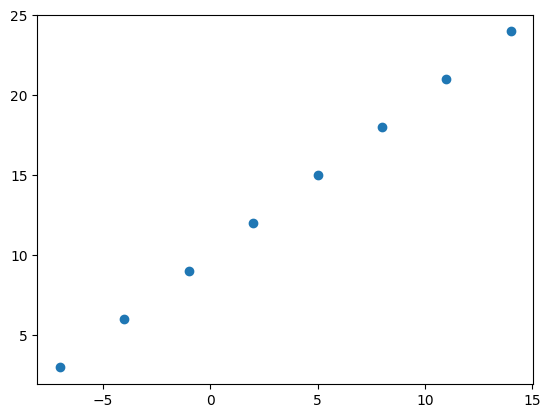

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create features
X = np.arange(start=-7.0, stop=15.0, step=3)

# Create labels
y = np.arange(3.0, 25., 3)

plt.scatter(X, y)

In [3]:
y == X + 10

# This is the relationship that hte regression should learn to model this data

array([ True,  True,  True,  True,  True,  True,  True,  True])

## Input and Output Shape

In [4]:
# Create a demo tensor for our hosuing price prediction problem
house_info = tf.constant(['bedroom', 'bathroom', 'garage'])
house_price = tf.constant([938000])
house_info ,house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([938000], dtype=int32)>)

In [5]:
X[0].ndim, X[0].shape

(0, ())

In [6]:
X = tf.constant(X)
y = tf.constant(y)
X, y

(<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

## Steps in modelling with TensorFlow

- Creating a model - define input, hidden and output layers  
- Compiling a model - define the loss function (calculated how wrong the model is) and optimizer (how to use the claculated loss to adjust weights) and evaluation matrices.
- Fitting a model - Train the model

In [7]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model using the Sequential API
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Setup the loss function
loss = tf.keras.losses.mae # mean absolute error
optimizer = tf.keras.optimizers.SGD() # stochastic gradient descent
model.compile(loss=loss, optimizer=optimizer, metrics=['mae'])

# 3. Fit the model
model.fit(tf.expand_dims(X, 1), y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - loss: 9.0221 - mae: 9.0221
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 8.8896 - mae: 8.8896
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 8.7571 - mae: 8.7571
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 8.6246 - mae: 8.6246
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 8.4921 - mae: 8.4921


In [8]:
# Trying to make a prediction
model.predict(tf.constant([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([[24.77467]], dtype=float32)

## Improve the model

Improved by doing better the steps taken to create the model:
- Add more layers, increase num. of neurons within each layer, activation within each layer
- Change optimizer, loss funciton
- Train for more epochs, have more train data

In [9]:
# Let's rebuild the model

# 1. Create the model
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(1))

# 2. Compile the model
model.compile(optimizer=tf.keras.optimizers.SGD(),
              loss=tf.keras.losses.mae,
              metrics=['mae', 'mse'])

# 3. Fit the Model
model.fit(tf.expand_dims(X, 1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - loss: 9.2888 - mae: 9.2888 - mse: 88.2325
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 9.1563 - mae: 9.1563 - mse: 86.5185
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 9.0238 - mae: 9.0238 - mse: 84.9554
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 8.8913 - mae: 8.8913 - mse: 83.5432
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 8.7588 - mae: 8.7588 - mse: 82.2818
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 8.6263 - mae: 8.6263 - mse: 81.1713
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 8.4938 - mae: 8.4938 - mse: 80.2117
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 8.3613 - mae: 8.3613 - mse: 79.4030
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 8.2288 - mae: 8.2288 - mse: 78.7451
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 8.0963 - mae: 8.0963 - mse: 78.2381
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss:

In [10]:
# Evaluate the model
model.predict(tf.constant([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


array([[30.166988]], dtype=float32)

In [11]:
import keras
# Remake a newer model

# 1. Make a model
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(1))

# 2. Compile modle
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = tf.keras.losses.mae,
    metrics = [keras.metrics.RootMeanSquaredError()]
)

# 3. Fit the model
model.fit(tf.expand_dims(X, 1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step - loss: 13.4157 - root_mean_squared_error: 14.9994
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 13.4112 - root_mean_squared_error: 14.9923
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 13.4067 - root_mean_squared_error: 14.9852
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 13.4022 - root_mean_squared_error: 14.9781
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 13.3977 - root_mean_squared_error: 14.9710
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 13.3932 - root_mean_squared_error: 14.9639
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 13.3887 - root_mean_squared_error: 14.9568
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 13.3842 - root_mean_squared_error: 14.9497
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 13.3797 - root_mean_squared_error: 14.9426
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 13.3752 - root_mean_squared_err

In [12]:
test_input = tf.constant([17.0])

In [13]:
## Make architectural layers

# 1. Create the model
model = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(50, activation=None),
        tf.keras.layers.Dense(1)
    ]
)

# 2. Compile model
model.compile(loss='mae',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['mae'])

# 3. Train the model
model.fit(tf.expand_dims(X, 1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 12.3769 - mae: 12.3769
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 11.6877 - mae: 11.6877
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 10.9901 - mae: 10.9901
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 10.2820 - mae: 10.2820
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 9.5615 - mae: 9.5615
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 8.8274 - mae: 8.8274
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 8.0781 - mae: 8.0781
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 7.3116 - mae: 7.3116
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 6.8535 - mae: 6.8535
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 7.0363 - mae: 7.0363
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 7.3089 - mae: 7.3089
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 7.4967 - mae: 7.4967
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43

In [14]:
# 4. Evaluate the model
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([[26.359112]], dtype=float32)

## Evaluating the Model

In practice the typical model developement lifecycle is:

```
create -> complie -> fit -> evaluate -> tweak -> .... (REPEAT)
```

When it comes to evaluation, visualization reigns king:
- The data
- The model
- The training of model
- The predictions of model

In [15]:
# Make a bigger dataset
X = tf.range(-100, 100, 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [16]:
# Make the labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

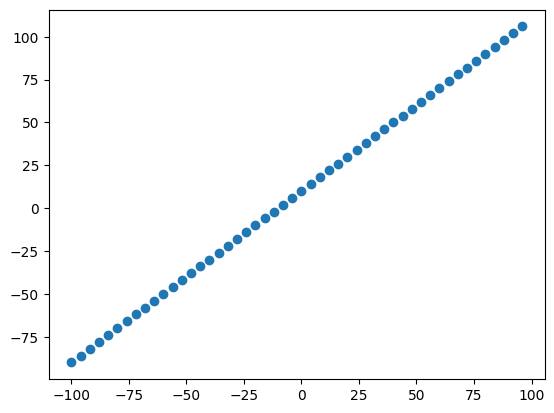

In [17]:
# Viaulaize the data
plt.scatter(X, y)

### Data Spliting

- Training set - the model learns from this data, which is typically 70-80% of the total data you hae available.
- Validation set - the model gets tuned on this data, which is typically 10-15% of the total
- Test set - the model is tested on this data, which is typically 10-15% of the total

In [18]:
# Check the length of samples we have
len(X)

50

In [19]:
# Split the data into test adn train sets
X_train, X_test = X[:40], X[40:]
y_train, y_test = y[:40], y[40:]
len(y_train), len(X_test)

(40, 10)

## Visualizing Data

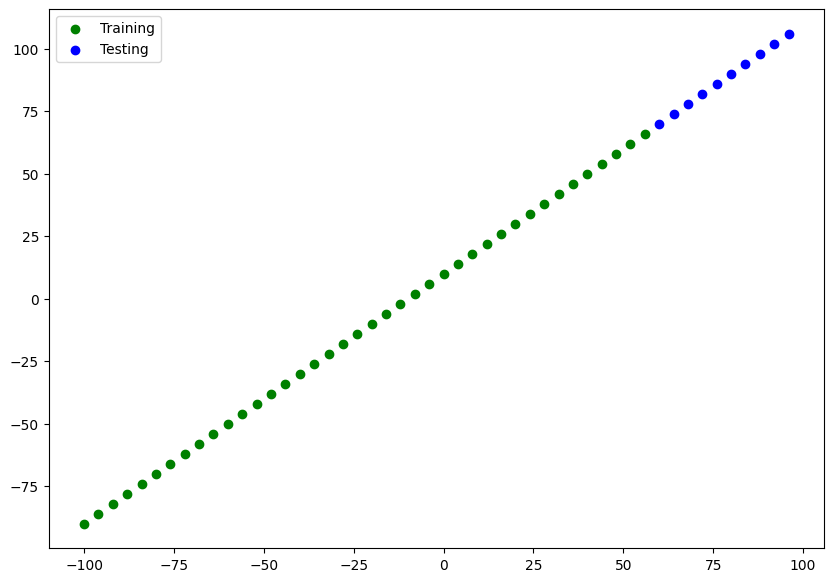

In [20]:
plt.figure(figsize=(10, 7))

plt.scatter(X_train, y_train, label='Training', c='g')
plt.scatter(X_test, y_test, label='Testing', c='b')
plt.legend()

# Let's have a look at how to buiild the neural network for the data

# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    # tf.keras.layers.Dense(100)
])

# 2. Compile the model
model.compile(optimizer=tf.keras.optimizers.SGD(),
    # optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss=tf.keras.losses.mae,
              metrics=['mse'])

# 3. Train the model
model.fit(tf.expand_dims(X_train, 1), y_train, epochs=100)

In [58]:
# Define a model with input_shape defined so that the build method of model works and we can visualize the model structure

tf.random.set_seed(42)

# Create model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name='input_layer'),
    tf.keras.layers.Dense(1, name='output_layer')
], name='one_of_many_models_we_are_going_to_build')

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.SGD(),
    loss=tf.keras.losses.mae,
    metrics = ['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "one_of_many_models_we_are_going_to_build"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [59]:
# Train model
model.fit(tf.expand_dims(X_train, 1), y_train, epochs=75, verbose=0)

In [60]:
# Get a summary of our model
model.summary()

Model: "one_of_many_models_we_are_going_to_build"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

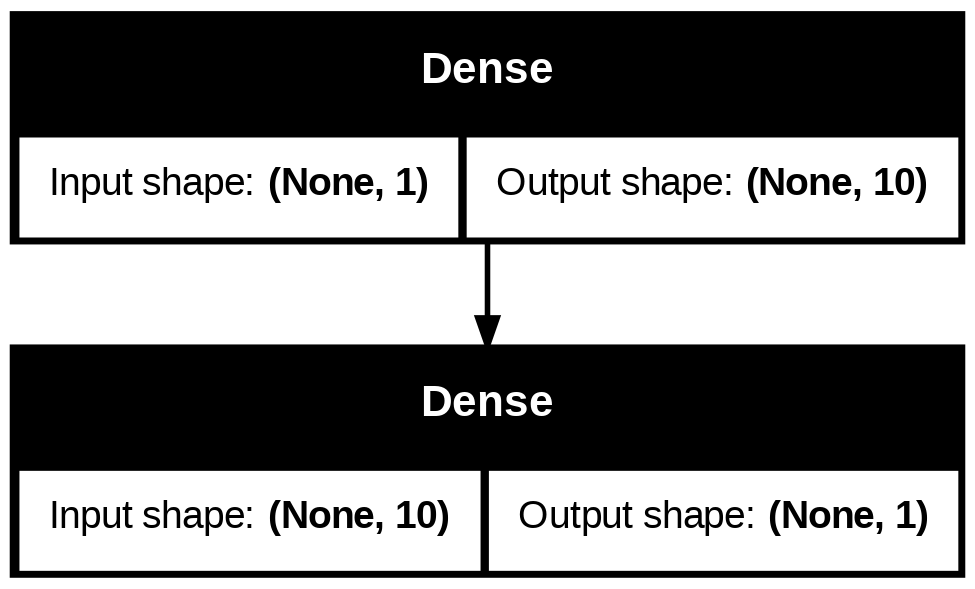

In [61]:
from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


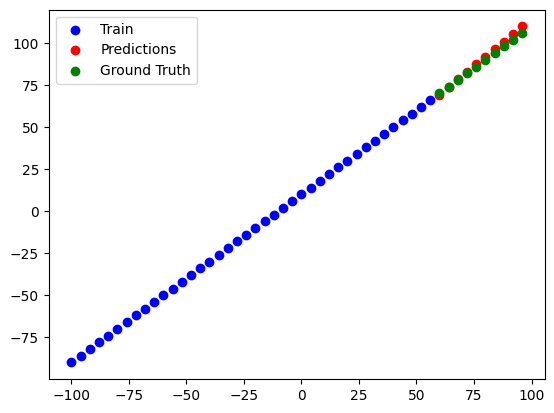

In [62]:
# Visualizing models predictions
y_pred = model.predict(tf.expand_dims(X_test, 1))

plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test, y_pred, c='r', label='Predictions')
plt.scatter(X_test, y_test, c='g', label='Ground Truth')

plt.legend()

In [63]:
# Plotting function
def plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    test_predictions=y_pred
):
  """
  Plots training and testing data
  """
  plt.figure(figsize=(10,7))

  # plot the training data
  plt.scatter(train_data, train_labels, c='b', label='Train data')
  # plot the testing data
  plt.scatter(test_data, test_labels, c='g', label='Test Data')
  # plot the predictions data
  plt.scatter(test_data, test_predictions, c='r', label='Predictions')

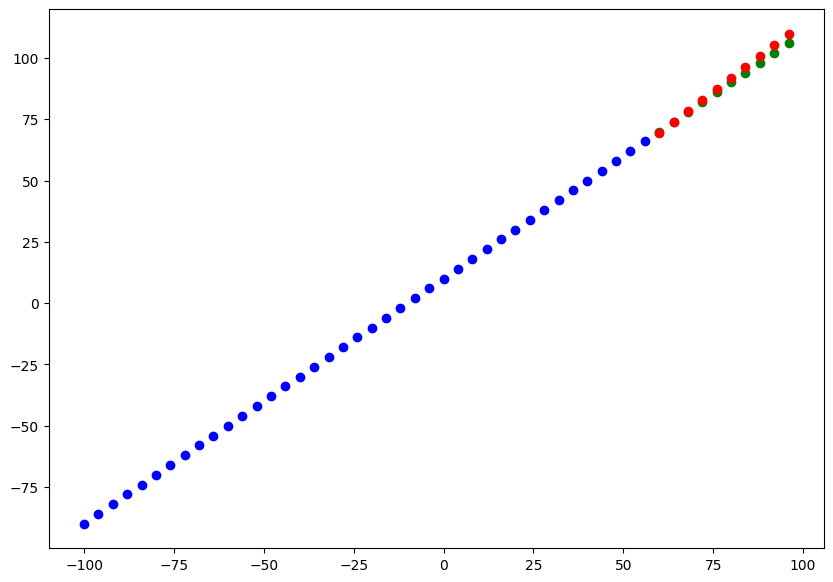

In [64]:
plot_predictions()

### Evaluating model's predictions with regression evaluation metrics

Best evaluation metric for regression model:
- MAE: mean absolute error
- MSE: mean square error

In [65]:
# Evaluate the model on test set
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 1.7673 - mae: 1.7673


[1.7673240900039673, 1.7673240900039673]

In [71]:
y_pred.shape , y_test.shape

((10, 1), TensorShape([10]))

In [72]:
# Calculate the mean absolute error
mae_error = tf.metrics.MAE(y_test, y_pred.squeeze())
mae_error

<tf.Tensor: shape=(), dtype=float32, numpy=1.7673240900039673>

In [76]:
mse_error = tf.metrics.MSE(y_test, y_pred.squeeze())
mse_error

<tf.Tensor: shape=(), dtype=float32, numpy=4.660912990570068>

In [94]:
# Making funcitons to resuse MAE and MSE
def mae(y_test, y_pred):
  return tf.metrics.MAE(y_test, y_pred.squeeze())
def mse(y_test, y_pred):
  return tf.metrics.MSE(y_test, y_pred.squeeze())

### Running experiments to improve model

1. Get more data
2. Make the model larger
3. Train for longer

  a. 1 layer, 100 epochs
  
  b. 2 layers, 300 epochs
  
  c. 2 layers, 500 epochs

In [78]:
X_train, y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>)

#### 1. model - 1 layer, 100 epochs

In [88]:
tf.random.set_seed(42)

# 1. Create the model
model_1 = tf.keras.Sequential()
model_1.add(tf.keras.layers.Dense(1))

# 2. Compile the model
model_1.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['mae','mse']
)

# 3. Fit the model
model_1.fit(tf.expand_dims(X_train,1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 27.2769 - mae: 27.2769 - mse: 1054.2433 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 9.9260 - mae: 9.9260 - mse: 104.1214   
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 11.3471 - mae: 11.3471 - mse: 153.8840
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 8.8925 - mae: 8.8925 - mse: 103.3910
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 10.0019 - mae: 10.0019 - mse: 105.9837
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 11.4767 - mae: 11.4767 - mse: 160.7867 
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 8.9683 - mae: 8.9683 - mse: 100.7023
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 10.0777 - mae: 10.0777 - mse: 108.3355
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 11.6096 - mae: 11.6096 - mse: 168.1789
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 12.6408 - mae: 12.6408 - mse: 211.8433 
Epoch 11/100
2/2 ━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


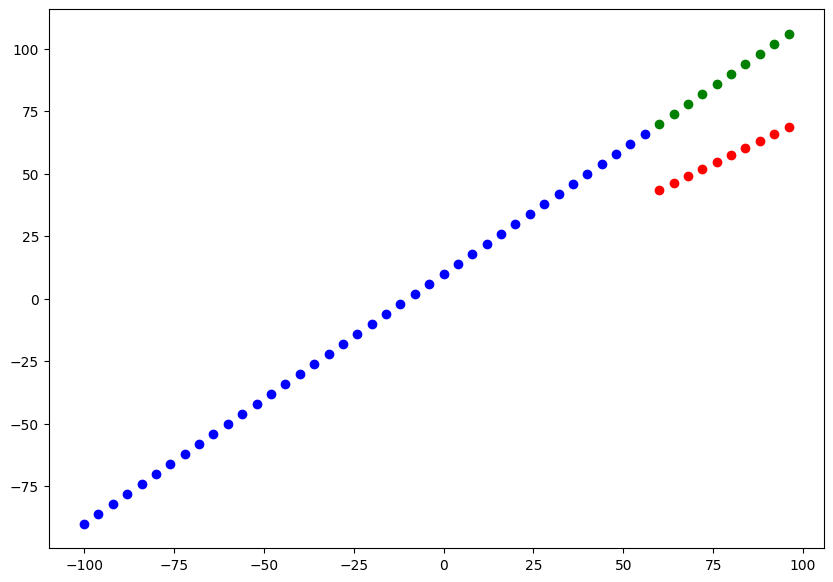

In [92]:
y_preds_1 = model_1.predict(X_test)
plot_predictions(test_predictions=y_preds_1)

In [95]:
# Calculate model_1 evaluation metrics
mae_1 = mae(y_test, y_preds_1)
mse_1 = mse(y_test, y_preds_1)
mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=32.0446662902832>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1038.800537109375>)

#### model_2: 2 layers, trained for a 100 epochs

In [99]:
# Set seed
tf.random.set_seed(42)

# Define model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])

# Compile model
model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['mse']
)

# Fit model
model_2.fit(tf.expand_dims(X_train, 1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 29.3972 - mse: 1305.8350
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 24.0667 - mse: 823.0641
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 22.3635 - mse: 685.5399
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 19.2190 - mse: 505.5191
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 17.6293 - mse: 426.0200
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 16.9919 - mse: 392.1491
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 12.5006 - mse: 252.3759
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 14.9792 - mse: 317.1021
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 15.6311 - mse: 331.6940
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 12.2961 - mse: 239.3525
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 14.8631 - mse: 308.6774
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 11.4557 - mse: 216.6964
Epoch 13/100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


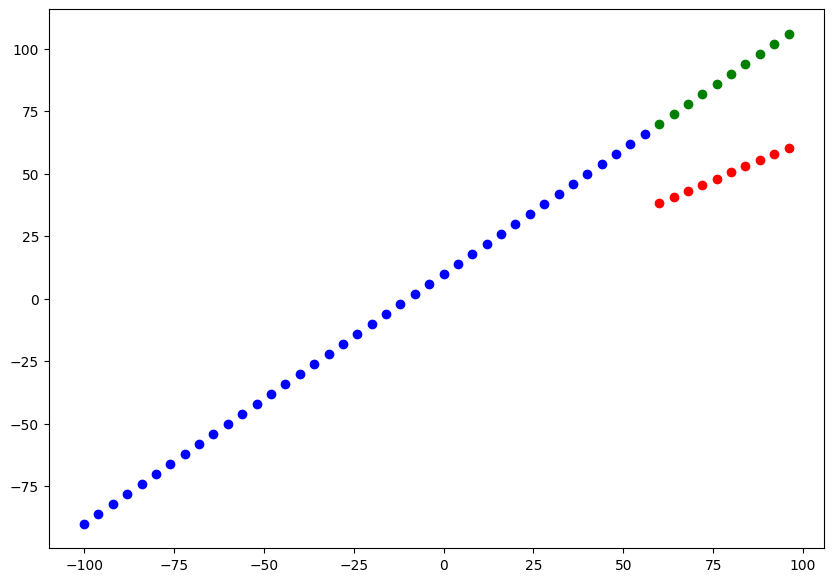

In [101]:
y_pred_2 = model_2.predict(tf.expand_dims(X_test,1))
plot_predictions(test_predictions=y_pred_2)

In [102]:
# Calculate evaluation metrics
mae_2 = mae(y_test, y_pred_2)
mse_2 = mse(y_test, y_pred_2)
mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=38.694435119628906>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1517.1527099609375>)

#### model_3: 2 layers, 5o0 epochs

In [105]:
# Set random seed
tf.random.set_seed(42)

# Make the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])

# Compile model
model_3.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.SGD(),
    metrics=['mae','mse']
)

# Fit model
model_3.fit(tf.expand_dims(X_train,1), y_train, epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 31.1749 - mae: 31.1749 - mse: 1348.5604 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 26.6212 - mae: 26.6212 - mse: 987.7723  
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 16.3856 - mae: 16.3856 - mse: 423.6254
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 19.1686 - mae: 19.1686 - mse: 497.1775 
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 13.5851 - mae: 13.5851 - mse: 299.9683
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 17.9557 - mae: 17.9557 - mse: 431.2862
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 13.9495 - mae: 13.9495 - mse: 292.2425
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 15.0343 - mae: 15.0343 - mse: 316.9799
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 15.7522 - mae: 15.7522 - mse: 334.9979
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 12.4271 - mae: 12.4271 - mse: 238.9328
Epoch 11/500
2/2 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


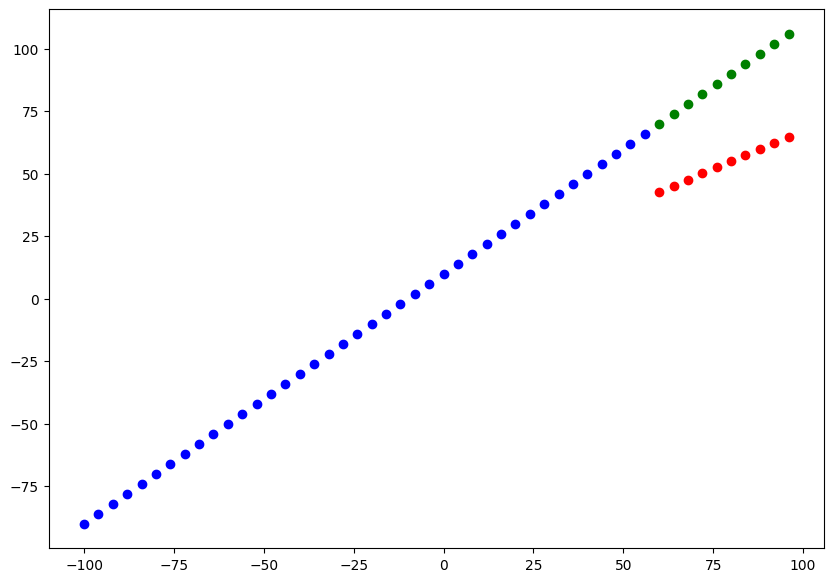

In [106]:
y_pred_3 = model_3.predict(tf.expand_dims(X_test,1))
plot_predictions(test_predictions=y_pred_3)

In [107]:
mae_3 = mae(y_test, y_pred_3)
mse_3 = mse(y_test, y_pred_3)
mae_3, mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=34.22220993041992>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1191.4739990234375>)

## Comparing the results of experiments

In [112]:
# Using pandas dataframe
import pandas as pd

model_results= [
    ['model_1', mae_1.numpy(), mse_1.numpy()],
    ['model_2', mae_2.numpy(), mse_2.numpy()],
    ['model_3', mae_3.numpy(), mse_3.numpy()],
]

all_results = pd.DataFrame(model_results, columns=['model','mae','mse'])

In [113]:
all_results

,model,mae,mse
0,model_1,32.044666,1038.800537
1,model_2,38.694435,1517.152710
2,model_3,34.222210,1191.473999


In [114]:
model_1.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Tracking experiments

Always track results of the experiments

Tools to help with tracking:
- TensorBoard: component of TensorFlow library, to track modelling experiments
- Weights & Biases: tool for tracking all kinds of ML experiments, fits right into TensorBoard


## Saving our models

Saving models allows for running them outside of Google Colab

2 main formats:
- The SavedModel format
- The HDF5 format

In [121]:
# Save model
model_1.save('best_model_SavedModel_format.keras')

In [122]:
# save model in hdf5
model_1.save('best_model_hd_format.h5')

## Loading in a saved model

In [123]:
# Load in the SavedModel format model
loaded_SavedModel_format = tf.keras.models.load_model('best_model_SavedModel_format.keras')
loaded_SavedModel_format.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [131]:
# Compare saved model with model_1
model_1_preds = model_1.predict(X_test)
loaded_SavedModel_format_preds = loaded_SavedModel_format.predict(tf.expand_dims(X_test, 1))
model_1_preds == loaded_SavedModel_format_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [132]:
loaded_keras_model = tf.keras.models.load_model('best_model_hd_format.h5')
loaded_keras_model_preds = loaded_keras_model.predict(tf.expand_dims(X_test,1))
model_1_preds == loaded_keras_model_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

## Model download from Google Colab

In [133]:
# download a file from Google Colab
from google.colab import files

files.download('best_model_hd_format.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# A Larger Example

In [134]:
# Import the required libraries
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [135]:
# Read the insurance dataset
insurance = pd.read_csv('https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv')

In [136]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [138]:
insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,True,False,False,True,False,False
1334,18,31.920,0,2205.98080,True,False,True,False,True,False,False,False
1335,18,36.850,0,1629.83350,True,False,True,False,False,False,True,False
1336,21,25.800,0,2007.94500,True,False,True,False,False,False,False,True


In [142]:
# Create data input and labels
X = insurance_one_hot.drop('charges', axis=1)
y = insurance_one_hot['charges']

In [143]:
X.head(), y.head()

(   age     bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
 0   19  27.900         0        True     False      False        True   
 1   18  33.770         1       False      True       True       False   
 2   28  33.000         3       False      True       True       False   
 3   33  22.705         0       False      True       True       False   
 4   32  28.880         0       False      True       True       False   
 
    region_northeast  region_northwest  region_southeast  region_southwest  
 0             False             False             False              True  
 1             False             False              True             False  
 2             False             False              True             False  
 3             False              True             False             False  
 4             False              True             False             False  ,
 0    16884.92400
 1     1725.55230
 2     4449.46200
 3    21984.47061
 4     3866.85520
 

In [144]:
# Create training and test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
len(X_train), len(X_test), len(X)

(1070, 268, 1338)

In [147]:
# Building a new model
# set seed
tf.random.set_seed(42)

# create model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile modle
insurance_model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['mae']
)

# Fit model
insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8698.3896 - mae: 8698.3896  
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7723.9795 - mae: 7723.9795 
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7849.9727 - mae: 7849.9727 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7260.1592 - mae: 7260.1592
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7626.5142 - mae: 7626.5142
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7502.3530 - mae: 7502.3530
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7795.4634 - mae: 7795.4634
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7357.8105 - mae: 7357.8105
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7695.0449 - mae: 7695.0449
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7820.2510 - mae: 7820.2510
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7625.3081 - mae: 7625.3081
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s

In [148]:
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5905.4229 - mae: 5905.4229  


[5905.4228515625, 5905.4228515625]

In [150]:
X_train.shape, y_train.shape

((1070, 11), (1070,))

In [151]:
insurance_preds = insurance_model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


## Model performing very bad, need to change hyper params.

1. Add an extra layer with more hidden units
2. Train for longer
3. Change hidden layer size (more nuerons)

In [161]:
# Set random seed
tf.random.set_seed(42)

# Make model
insurance_model_2 = tf.keras.Sequential()
insurance_model_2.add(tf.keras.layers.Dense(100))
insurance_model_2.add(tf.keras.layers.Dense(10))
insurance_model_2.add(tf.keras.layers.Dense(1))

# Compile model
insurance_model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mse','mae',]
)

# Fit model
insurance_model_2.fit(X_train, y_train, epochs=100, verbose=0)

In [162]:
# Evaluate the larger model
insurance_model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4806.0469 - mae: 4806.0469 - mse: 96299880.0000   


[4806.046875, 96299880.0, 4806.046875]

In [171]:
# Set seed
tf.random.set_seed(42)

# create the model
insurance_model_3 = tf.keras.Sequential()
insurance_model_3.add(tf.keras.layers.Dense(100))
insurance_model_3.add(tf.keras.layers.Dense(10))
insurance_model_3.add(tf.keras.layers.Dense(1))

# compile the model
insurance_model_3.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae', 'mse']
)

# fit model
history = insurance_model_3.fit(X_test, y_test, epochs=300)

Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 12962.1816 - mae: 12962.1816 - mse: 323241792.0000
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12929.7432 - mae: 12929.7432 - mse: 322326688.0000 
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12895.3154 - mae: 12895.3154 - mse: 321356288.0000 
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12856.5762 - mae: 12856.5762 - mse: 320266208.0000 
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12811.1201 - mae: 12811.1201 - mse: 318990752.0000 
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12756.4570 - mae: 12756.4570 - mse: 317463296.0000 
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12690.0293 - mae: 12690.0293 - mse: 315616576.0000 
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12609.1924 - mae: 12609.1924 - mse: 313383232.0000 
Epoch 9/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12511.1816 - mae: 12511.1816 - mse: 310695232.0000 
Epoch 10/300
9/9 ━━━

In [172]:
#Evaluate new model
insurance_model_3.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5643.2510 - mae: 5643.2510 - mse: 130698088.0000  


[5643.2509765625, 5643.2509765625, 130698088.0]

Text(0.5, 0, 'epochs')

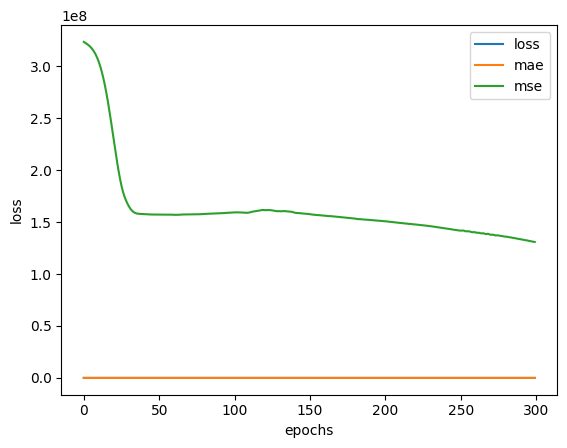

In [173]:
# Plot history
pd.DataFrame(history.history).plot()
plt.ylabel('loss')
plt.xlabel('epochs')

## Normalization and Standardization

<Axes: ylabel='Frequency'>

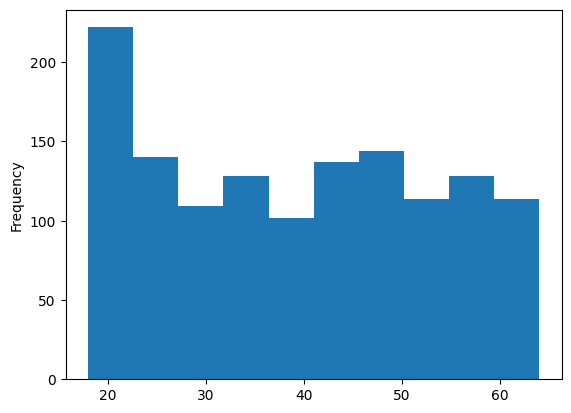

In [174]:
X['age'].plot(kind='hist')

<Axes: ylabel='Frequency'>

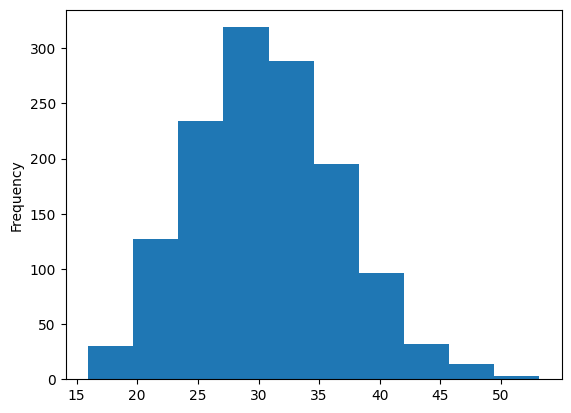

In [175]:
X['bmi'].plot(kind='hist')

## Preprocessing

In [176]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Read in insurance dataframe
insurance = pd.read_csv('https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv')
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [178]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Create a column transformer
ct = make_column_transformer(
    (MinMaxScaler(), ['age', 'bmi', 'children']),
    (OneHotEncoder(handle_unknown='ignore'), ['sex', 'smoker', 'region'])
)

# Create X and y
X = insurance.drop('charges', axis=1)
y = insurance['charges']

# Train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Fit the column transformer to our training data
ct.fit(X_train)

# Transfrom training and test data with normalization
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [180]:
X_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

### Build a new model

In [181]:
# Set seed
tf.random.set_seed(42)

# Create a model
insurance_model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])

# Compile model
insurance_model_4.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae']
)

# FIt the model
insurance_model_4.fit(X_train_normal, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 13343.6533 - mae: 13343.6533
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13333.7793 - mae: 13333.7793
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13308.6191 - mae: 13308.6191
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13256.7500 - mae: 13256.7500
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13167.0859 - mae: 13167.0859
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13029.0459 - mae: 13029.0459
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12832.2412 - mae: 12832.2412
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12566.8398 - mae: 12566.8398
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12223.4863 - mae: 12223.4863
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11800.1904 - mae: 11800.1904
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11312.1553 - mae: 11312.1553
Epoch 12/100
34/34 ━━━━━━━━━━━

In [183]:
#Evaluate the new model
insurance_model_4.evaluate(X_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3427.4331 - mae: 3427.4331 


[3427.43310546875, 3427.43310546875]

# Regression Exercises

In [203]:
from tensorflow.keras.datasets import boston_housing

(X_train, y_train), (X_test, y_test) = boston_housing.load_data(path='housing.npz', test_split=0.2, seed=42)

columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX",
    "RM", "AGE", "DIS", "RAD", "TAX",
    "PTRATIO", "B", "LSTAT"
]

In [207]:
train_df = pd.DataFrame(X_train, columns=columns)
test_df = pd.DataFrame(X_test, columns=columns)
train_df, test_df

(        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS   RAD    TAX  \
 0    0.09178   0.0   4.05   0.0  0.510  6.416  84.1  2.6463   5.0  296.0   
 1    0.05644  40.0   6.41   1.0  0.447  6.758  32.9  4.0776   4.0  254.0   
 2    0.10574   0.0  27.74   0.0  0.609  5.983  98.8  1.8681   4.0  711.0   
 3    0.09164   0.0  10.81   0.0  0.413  6.065   7.8  5.2873   4.0  305.0   
 4    5.09017   0.0  18.10   0.0  0.713  6.297  91.8  2.3682  24.0  666.0   
 ..       ...   ...    ...   ...    ...    ...   ...     ...   ...    ...   
 399  9.39063   0.0  18.10   0.0  0.740  5.627  93.9  1.8172  24.0  666.0   
 400  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889   1.0  273.0   
 401  0.03041   0.0   5.19   0.0  0.515  5.895  59.6  5.6150   5.0  224.0   
 402  0.52058   0.0   6.20   1.0  0.507  6.631  76.5  4.1480   8.0  307.0   
 403  0.25199   0.0  10.59   0.0  0.489  5.783  72.7  4.3549   4.0  277.0   
 
      PTRATIO       B  LSTAT  
 0       16.6  395.50   9.04  
 1       17.

In [205]:
y_train

array([23.6, 32.4, 13.6, 22.8, 16.1, 20. , 17.8, 14. , 19.6, 16.8, 21.5,
       18.9,  7. , 21.2, 18.5, 29.8, 18.8, 10.2, 50. , 14.1, 25.2, 29.1,
       12.7, 22.4, 14.2, 13.8, 20.3, 14.9, 21.7, 18.3, 23.1, 23.8, 15. ,
       20.8, 19.1, 19.4, 34.7, 19.5, 24.4, 23.4, 19.7, 28.2, 50. , 17.4,
       22.6, 15.1, 13.1, 24.2, 19.9, 24. , 18.9, 35.4, 15.2, 26.5, 43.5,
       21.2, 18.4, 28.5, 23.9, 18.5, 25. , 35.4, 31.5, 20.2, 24.1, 20. ,
       13.1, 24.8, 30.8, 12.7, 20. , 23.7, 10.8, 20.6, 20.8,  5. , 20.1,
       48.5, 10.9,  7. , 20.9, 17.2, 20.9,  9.7, 19.4, 29. , 16.4, 25. ,
       25. , 17.1, 23.2, 10.4, 19.6, 17.2, 27.5, 23. , 50. , 17.9,  9.6,
       17.2, 22.5, 21.4, 12. , 19.9, 19.4, 13.4, 18.2, 24.6, 21.1, 24.7,
        8.7, 27.5, 20.7, 36.2, 31.6, 11.7, 39.8, 13.9, 21.8, 23.7, 17.6,
       24.4,  8.8, 19.2, 25.3, 20.4, 23.1, 37.9, 15.6, 45.4, 15.7, 22.6,
       14.5, 18.7, 17.8, 16.1, 20.6, 31.6, 29.1, 15.6, 17.5, 22.5, 19.4,
       19.3,  8.5, 20.6, 17. , 17.1, 14.5, 50. , 14

In [206]:
# Normalize and standardize data
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer

ct = make_column_transformer(
    (StandardScaler(), columns)
)

# Fit the transformer to training data
ct.fit(train_df)

ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
                                  'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B',
                                  'LSTAT'])])

In [208]:
# Apply normalization
X_train_normal = ct.transform(train_df)
X_test_normal = ct.transform(test_df)

In [211]:
#Set seed
tf.random.set_seed(42)

housing_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1000),
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])

housing_model.compile(
    loss=tf.keras.losses.mse,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['mse']
)

housing_model.fit(X_train_normal, y_train, epochs=300)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 389.4063 - mse: 389.4063
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 53.8162 - mse: 53.8162
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 31.3570 - mse: 31.3570
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 27.2119 - mse: 27.2119
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 27.0579 - mse: 27.0579
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 26.9902 - mse: 26.9902
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 26.2626 - mse: 26.2626
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 24.8027 - mse: 24.8027
Epoch 9/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 24.6218 - mse: 24.6218
Epoch 10/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 24.8042 - mse: 24.8042
Epoch 11/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 24.8088 - mse: 24.8088
Epoch 12/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 24.7488 - mse: 24.7488


In [212]:
#Evaluate the new boston house 4 layer deep model
housing_model.evaluate(X_test_normal, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 22.3656 - mse: 22.3656  


[22.36563491821289, 22.36563491821289]